# Analysis Without GSM8K Records

This notebook filters out all GSM8K records and analyzes only the algorithmic tasks:
- CLRS (classic algorithms)
- NPHard (NP-hard problems)
- Fine-grained (arithmetic/dynamic programming)

GSM8K is excluded because it's a different task type (math word problems) that doesn't fit the algorithmic focus.

In [1]:
import json
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path for imports
PROJECT_ROOT = Path("../../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.exps_performance.logger import create_big_df

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

RESULTS_DIR = Path("../results")
JSON_ERROR_THRESHOLD = 0.50  # 50% threshold

print(f"Results directory: {RESULTS_DIR.resolve()}")

Results directory: /Users/terrytong/Documents/CCG/ToolProj/src/exps_performance/results


## Load All Data

In [2]:
# Load all JSONL results
jsonl_files = sorted(RESULTS_DIR.rglob("*.jsonl"))
print(f"Found {len(jsonl_files)} JSONL files")

df_all = create_big_df(jsonl_files)
print(f"Loaded {len(df_all):,} total rows")
print(f"Models found: {df_all['model'].nunique()}")
print(f"Task kinds: {df_all['kind'].nunique()}")

Found 28 JSONL files


Loaded 44,850 total rows
Models found: 10
Task kinds: 49


## Filter Out GSM8K Records

In [3]:
# Check GSM8K presence before filtering
gsm8k_count = (df_all['kind'] == 'gsm8k').sum()
print(f"GSM8K records before filtering: {gsm8k_count:,}")

# Filter out GSM8K records
df = df_all[df_all['kind'] != 'gsm8k'].copy()

print(f"\n{'='*60}")
print("GSM8K FILTERING COMPLETE")
print(f"{'='*60}")
print(f"Records REMOVED (GSM8K): {gsm8k_count:,}")
print(f"Records REMAINING: {len(df):,}")
print(f"Data retained: {len(df)/len(df_all)*100:.1f}%")

# Verify no GSM8K remains
gsm8k_remaining = (df['kind'] == 'gsm8k').sum()
print(f"\nVerification - GSM8K records remaining: {gsm8k_remaining}")
assert gsm8k_remaining == 0, "ERROR: GSM8K records still present!"

GSM8K records before filtering: 4,500

GSM8K FILTERING COMPLETE
Records REMOVED (GSM8K): 4,500
Records REMAINING: 40,350
Data retained: 90.0%

Verification - GSM8K records remaining: 0


In [4]:
# Show remaining task distribution
print("\nRemaining task kinds:")
print(df['kind'].value_counts().head(20))


Remaining task kinds:
kind
sub                     1464
add                     1464
mul                     1464
lcs                     1464
rod                     1464
knap                    1464
ilp_assign              1464
segments_intersect      1457
ilp_prod                1419
spp                     1395
tsp                     1395
ksp                     1395
gcp                     1395
edp                     1395
ilp_partition           1392
naive_string_matcher    1248
quickselect             1147
tsp_d                   1140
msp                     1140
gcp_d                   1140
Name: count, dtype: int64


## Apply 50% JSON Error Filtering

In [5]:
def has_real_error(err_msg):
    """Check if err_msg indicates a REAL error."""
    if not err_msg or err_msg == '':
        return True
    err_msg = str(err_msg).lower().strip()
    return err_msg not in ['ok', 'ok,ok']

# Compute sim_err per row
df['sim_err'] = df['sim_err_msg'].apply(has_real_error)

# Compute per-model error rates
model_err_rates = df.groupby('model').agg({
    'sim_err': 'mean',
    'sim_correct': 'mean',
    'nl_correct': 'mean',
    'code_correct': 'mean',
}).reset_index()
model_err_rates.columns = ['model', 'sim_err_rate', 'sim_acc', 'nl_acc', 'code_acc']
model_err_rates = model_err_rates.sort_values('sim_err_rate', ascending=False)

print("Per-model simulation error rates (no GSM8K):")
print(model_err_rates.to_string(index=False))

Per-model simulation error rates (no GSM8K):
                             model  sim_err_rate  sim_acc   nl_acc  code_acc
      mistralai/ministral-14b-2512      0.215400 0.156000 0.163200  0.342800
  qwen/qwen-2.5-coder-32b-instruct      0.203207 0.115845 0.090235  0.084251
                openai/gpt-4o-mini      0.143400 0.166600 0.190800  0.352000
meta-llama/llama-3.1-405b-instruct      0.080059 0.154715 0.124754  0.139489
        anthropic/claude-haiku-4.5      0.027000 0.287800 0.319800  0.410200
           google/gemini-2.5-flash      0.001899 0.234810 0.241772  0.455696
  mistralai/mixtral-8x22b-instruct      0.001145 0.197328 0.134351  0.318511
       google/gemini-2.0-flash-001      0.000191 0.223282 0.233397  0.365267
          mistralai/codestral-2508      0.000000 0.222857 0.194762  0.407619
      mistralai/mistral-large-2411      0.000000 0.191358 0.000000  0.175154


In [6]:
# Filter models with <=50% error rate
good_models = model_err_rates[model_err_rates['sim_err_rate'] <= JSON_ERROR_THRESHOLD]['model'].tolist()
bad_models = model_err_rates[model_err_rates['sim_err_rate'] > JSON_ERROR_THRESHOLD]['model'].tolist()

print(f"Models KEPT (<=50% sim error): {len(good_models)}")
for m in good_models:
    rate = model_err_rates[model_err_rates['model']==m]['sim_err_rate'].iloc[0]
    print(f"  INCLUDED: {m} ({rate*100:.1f}% error)")

print(f"\nModels FILTERED OUT (>50% sim error): {len(bad_models)}")
for m in bad_models:
    rate = model_err_rates[model_err_rates['model']==m]['sim_err_rate'].iloc[0]
    print(f"  EXCLUDED: {m} ({rate*100:.1f}% error)")

# Apply model filter
df_filtered = df[df['model'].isin(good_models)].copy()

Models KEPT (<=50% sim error): 10
  INCLUDED: mistralai/ministral-14b-2512 (21.5% error)
  INCLUDED: qwen/qwen-2.5-coder-32b-instruct (20.3% error)
  INCLUDED: openai/gpt-4o-mini (14.3% error)
  INCLUDED: meta-llama/llama-3.1-405b-instruct (8.0% error)
  INCLUDED: anthropic/claude-haiku-4.5 (2.7% error)
  INCLUDED: google/gemini-2.5-flash (0.2% error)
  INCLUDED: mistralai/mixtral-8x22b-instruct (0.1% error)
  INCLUDED: google/gemini-2.0-flash-001 (0.0% error)
  INCLUDED: mistralai/codestral-2508 (0.0% error)
  INCLUDED: mistralai/mistral-large-2411 (0.0% error)

Models FILTERED OUT (>50% sim error): 0


## Generate Analysis Figure

Generating figure with filtered models (no GSM8K)...
[plot_v_graph_closed] Filtering to 44 task kinds
[plot_v_graph_closed] Kinds in data: ['activity_selector', 'add', 'articulation_points', 'bellman_ford', 'bfs', 'binary_search', 'bridges', 'bubble_sort', 'dag_shortest_paths', 'dfs', 'dijkstra', 'edp', 'find_maximum_subarray_kadane', 'floyd_warshall', 'gcp', 'graham_scan', 'heapsort', 'ilp_assign', 'ilp_partition', 'ilp_prod', 'insertion_sort', 'jarvis_march', 'kmp_matcher', 'knap', 'ksp', 'lcs', 'lcs_length', 'matrix_chain_order', 'minimum', 'mst_kruskal', 'mst_prim', 'mul', 'naive_string_matcher', 'optimal_bst', 'quickselect', 'quicksort', 'rod', 'segments_intersect', 'spp', 'strongly_connected_components', 'sub', 'task_scheduling', 'topological_sort', 'tsp']


[plot_v_graph_closed] Saved figures/line_closed.png

Figure saved to: /Users/terrytong/Documents/CCG/ToolProj/src/exps_performance/figures/line_closed.png


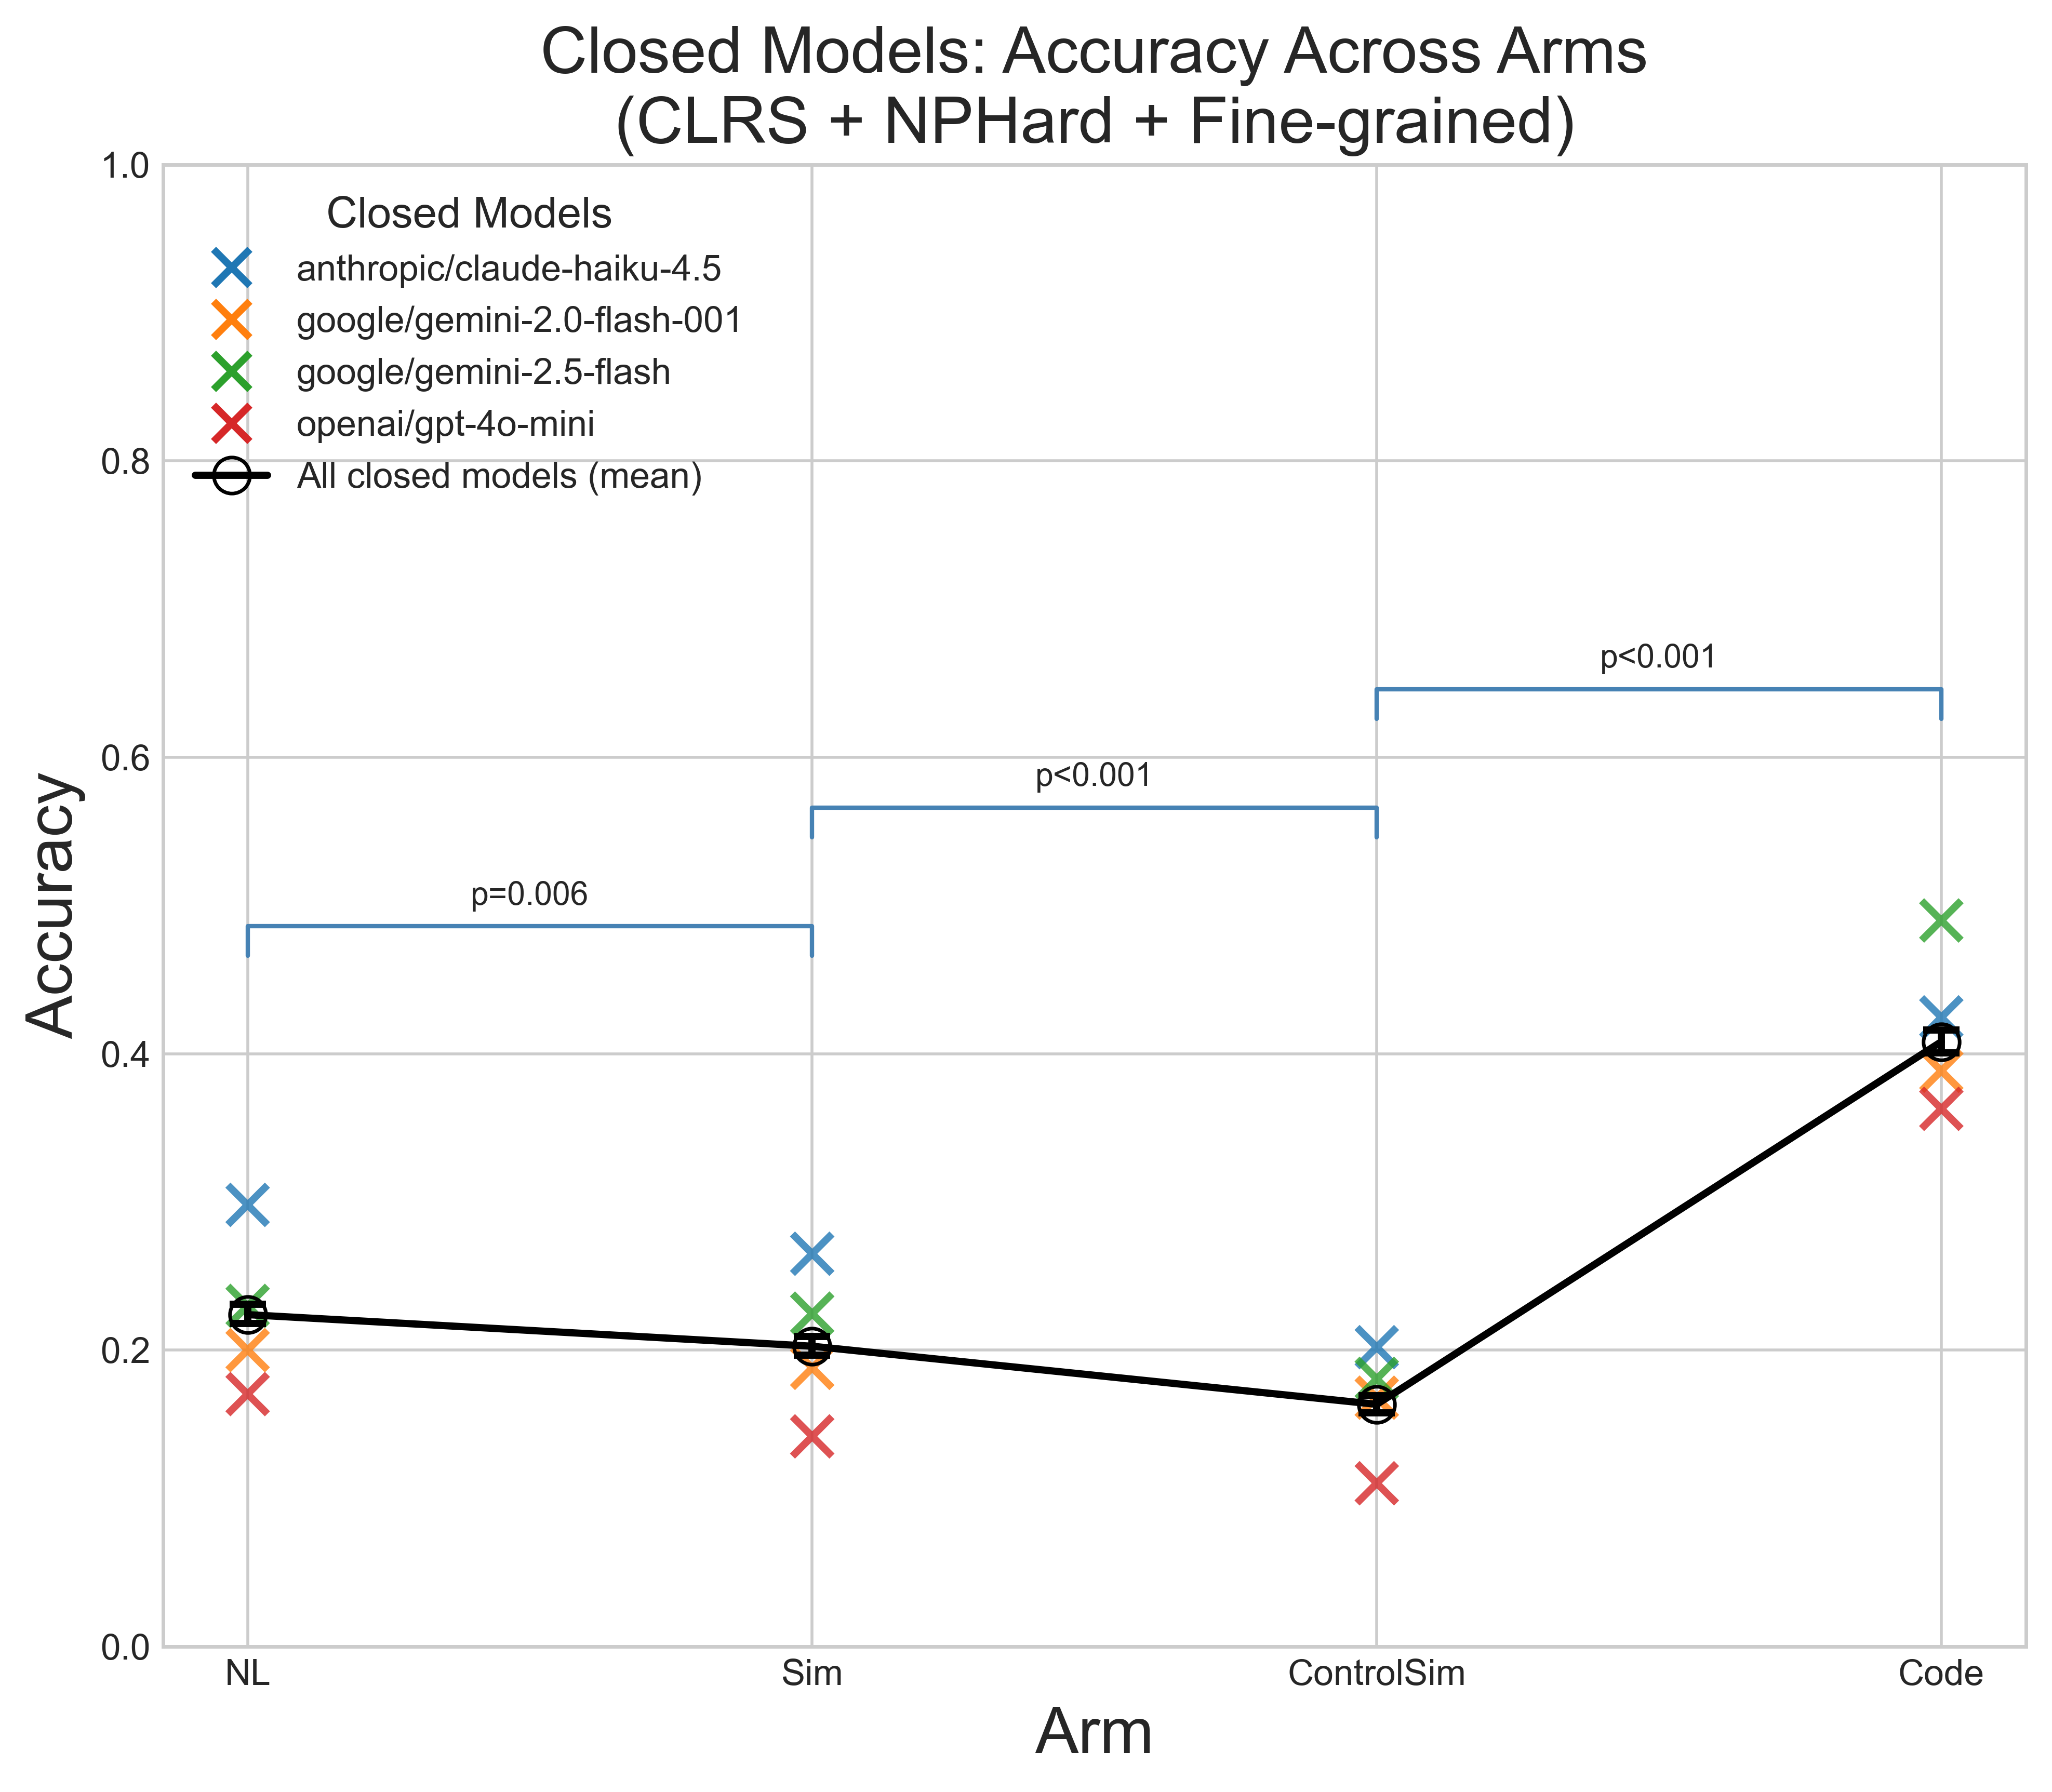

In [7]:
from src.exps_performance.analysis import plot_v_graph_closed

# Change to exps_performance directory for figure saving
exps_perf_dir = Path("..").resolve()
figures_dir = exps_perf_dir / "figures"
figures_dir.mkdir(exist_ok=True)

original_cwd = os.getcwd()
os.chdir(exps_perf_dir)

try:
    print("Generating figure with filtered models (no GSM8K)...")
    plot_v_graph_closed(df_filtered)
    print(f"\nFigure saved to: {figures_dir}/line_closed.png")
finally:
    os.chdir(original_cwd)

## Summary Statistics

In [8]:
print("="*70)
print("FINAL SUMMARY - NO GSM8K ANALYSIS")
print("="*70)

print(f"\n1. GSM8K Filtering:")
print(f"   - GSM8K records removed: {gsm8k_count:,}")
print(f"   - Records remaining: {len(df):,}")

print(f"\n2. JSON Error Filtering (50% threshold):")
print(f"   - Models kept: {len(good_models)}")
print(f"   - Models excluded: {len(bad_models)}")

print(f"\n3. Final Dataset:")
print(f"   - Total records: {len(df_filtered):,}")
print(f"   - Unique models: {df_filtered['model'].nunique()}")
print(f"   - Unique task kinds: {df_filtered['kind'].nunique()}")

print(f"\n4. Task Categories Included:")
CLRS_KINDS = {
    "activity_selector", "articulation_points", "bellman_ford", "bfs",
    "binary_search", "bridges", "bubble_sort", "dag_shortest_paths",
    "dfs", "dijkstra", "find_maximum_subarray_kadane", "floyd_warshall",
    "graham_scan", "heapsort", "insertion_sort", "jarvis_march",
    "kmp_matcher", "lcs_length", "matrix_chain_order", "minimum",
    "mst_kruskal", "mst_prim", "naive_string_matcher", "optimal_bst",
    "quickselect", "quicksort", "segments_intersect",
    "strongly_connected_components", "task_scheduling", "topological_sort",
}
NPHARD_KINDS = {"edp", "gcp", "ksp", "spp", "tsp"}
FG_KINDS = {"add", "sub", "mul", "lcs", "rod", "knap", "ilp_assign", "ilp_prod", "ilp_partition"}

kinds_in_data = set(df_filtered['kind'].unique())
print(f"   - CLRS tasks: {len(kinds_in_data & CLRS_KINDS)}")
print(f"   - NPHard tasks: {len(kinds_in_data & NPHARD_KINDS)}")
print(f"   - Fine-grained tasks: {len(kinds_in_data & FG_KINDS)}")
print(f"   - GSM8K tasks: {len(kinds_in_data & {'gsm8k'})} (should be 0)")

FINAL SUMMARY - NO GSM8K ANALYSIS

1. GSM8K Filtering:
   - GSM8K records removed: 4,500
   - Records remaining: 40,350

2. JSON Error Filtering (50% threshold):
   - Models kept: 10
   - Models excluded: 0

3. Final Dataset:
   - Total records: 40,350
   - Unique models: 10
   - Unique task kinds: 48

4. Task Categories Included:
   - CLRS tasks: 30
   - NPHard tasks: 5
   - Fine-grained tasks: 9
   - GSM8K tasks: 0 (should be 0)


In [9]:
# Per-model accuracy summary (no GSM8K)
print("\nPer-Model Accuracy (No GSM8K):")
print("-" * 70)

summary = df_filtered.groupby('model')[['code_correct', 'nl_correct', 'sim_correct']].mean().round(3)
summary = summary.sort_values('code_correct', ascending=False)
print(summary.to_string())


Per-Model Accuracy (No GSM8K):
----------------------------------------------------------------------
                                    code_correct  nl_correct  sim_correct
model                                                                    
google/gemini-2.5-flash                    0.456       0.242        0.235
anthropic/claude-haiku-4.5                 0.410       0.320        0.288
mistralai/codestral-2508                   0.408       0.195        0.223
google/gemini-2.0-flash-001                0.365       0.233        0.223
openai/gpt-4o-mini                         0.352       0.191        0.167
mistralai/ministral-14b-2512               0.343       0.163        0.156
mistralai/mixtral-8x22b-instruct           0.319       0.134        0.197
mistralai/mistral-large-2411               0.175       0.000        0.191
meta-llama/llama-3.1-405b-instruct         0.139       0.125        0.155
qwen/qwen-2.5-coder-32b-instruct           0.084       0.090        0.116
